In [ ]:
import kick_zscaler

In [2]:
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")

dataset

DatasetDict({
    train: Dataset({
        features: ['Titles', 'Abstracts', 'Years', 'Categories'],
        num_rows: 44949
    })
})

In [5]:
dataset["train"]

Dataset({
    features: ['Titles', 'Abstracts', 'Years', 'Categories'],
    num_rows: 44949
})

In [3]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from umap import UMAP  # 依赖 uv add umap-learn
from hdbscan import HDBSCAN # 依赖 uv add hdbscan

dataset = load_dataset("maartengr/arxiv_nlp")["train"] # [Titles, Abstracts, Years, Categories]

abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

# text embeddings
embedding_model = SentenceTransformer("thenlper/gte-small", device="mps")
embeddings = embedding_model.encode(abstracts, batch_size=10, device="mps", show_progress_bar=True)
print(embeddings.shape)  # (44949, 384)

# dimensionality reduction, 从 384 降到 5
umap_model = UMAP(n_components=5, min_dist=0.0, metric="cosine", random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)
print(reduced_embeddings.shape)  # (44949, 5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/4495 [00:00<?, ?it/s]

(44949, 384)


/Users/yanbin/Workspaces/github/Hands-On-Large-Language-Models/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(44949, 5)


In [3]:
from hdbscan import HDBSCAN
# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric="euclidean",
    cluster_selection_method="eom"
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_
# How many clusters did we generate?
len(set(clusters))

154

In [4]:
import numpy as np
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [5]:
import pandas as pd
# Reduce 384-dimensional embeddings to two dimensions for easiervisualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric="cosine"
    ,
    random_state=42
).fit_transform(embeddings)
# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]
,
    # Select outliers and non-outliers (clusters)
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]

/Users/yanbin/Workspaces/github/Hands-On-Large-Language-Models/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-7.033915638923645),
 np.float64(11.223850846290588),
 np.float64(-8.208207726478577),
 np.float64(10.93338692188263))

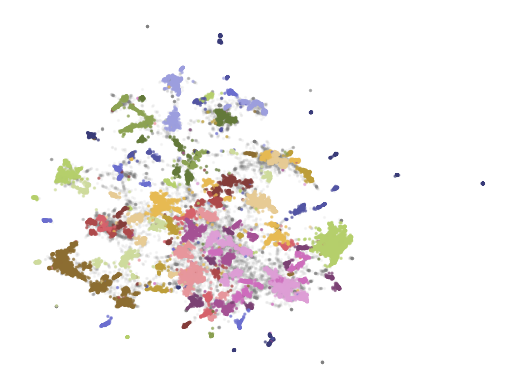

In [7]:
import matplotlib.pyplot as plt
# Plot outliers and non-outliers separately
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2,
            c="grey")
plt.scatter(
    to_plot.x, to_plot.y,
    c=to_plot.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b"
)
plt.axis("off")